In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Torch
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

# Transformaciones
from sklearn.preprocessing import StandardScaler
from scipy.signal import detrend

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os

In [2]:
def set_seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # si usas multi-GPU

    np.random.seed(seed)
    random.seed(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Semilla: {seed}")

set_seed_everything(46)

Semilla: 46


### Obtención de la serie CMAPSS Dataset

In [3]:
pd.set_option("display.max_columns", None)

ruta_dataset = 'data/raw_data/train_FD001.txt'

headers = [
    "unit_number",
    "time_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"]

headers += [f"sensor_{i}" for i in range(1, 22)]

In [4]:
df_FD001 = pd.read_csv(ruta_dataset, delim_whitespace=True, header=None, names=headers)
df_FD001.head()

/tmp/ipykernel_3528/1599241784.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_FD001 = pd.read_csv(ruta_dataset, delim_whitespace=True, header=None, names=headers)


,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
df = df_FD001.copy()
sensores = [f'sensor_{i}' for i in range(1,10)]
df = df[sensores]
df['conteo'] = range(1, len(df) + 1)
df = df[['conteo'] + sensores]

# Eliminar las columnas con valores constantes en sensores
constantes = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_7']
df = df.drop(columns=constantes)

df.head()

,conteo,sensor_2,sensor_3,sensor_4,sensor_8,sensor_9
0,1,641.82,1589.70,1400.60,2388.06,9046.19
1,2,642.15,1591.82,1403.14,2388.04,9044.07
2,3,642.35,1587.99,1404.20,2388.08,9052.94
3,4,642.35,1582.79,1401.87,2388.11,9049.48
4,5,642.37,1582.85,1406.22,2388.06,9055.15


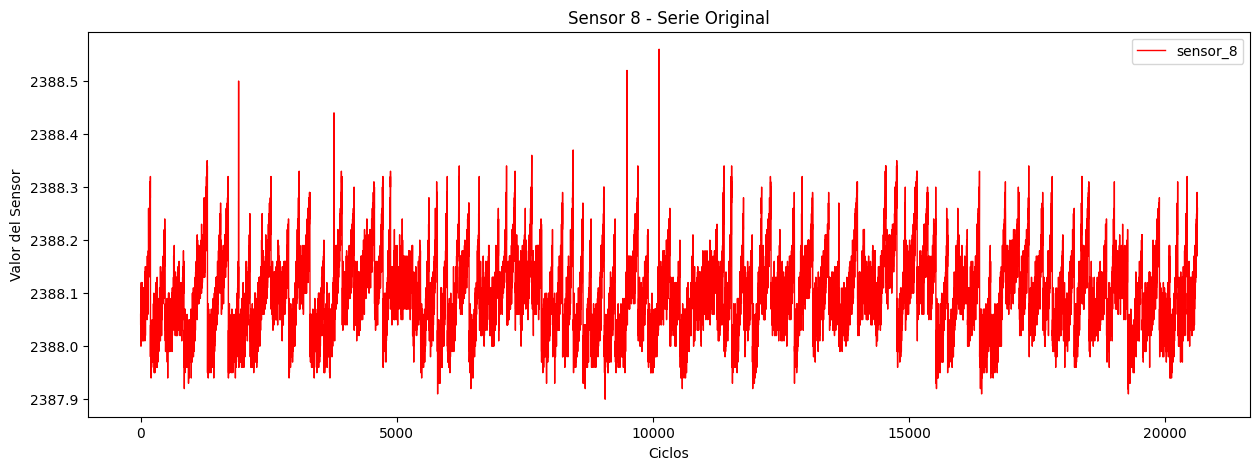

In [6]:
n_sensor = 8
df[f'sensor_{n_sensor}'].plot(title=f'Sensor {n_sensor} - Serie Original',
                    figsize=(15, 5),
                    color='red', 
                    linewidth=1, 
                    legend=True)
plt.xlabel('Ciclos'),
plt.ylabel('Valor del Sensor')
plt.show()

### Serie seleccionada para trabajar - 8

In [7]:
serie = df[[f'sensor_{n_sensor}']]
print('----- Dimensiones de la serie seleccionada -----')
print(serie.shape)
print('\n----- Estadísticas descriptivas de la serie seleccionada -----')
print(serie.describe())
print('\n----- Información de la serie seleccionada -----')
print(serie.info())
print('\n----- Valores nulos en la serie seleccionada -----')
print(serie.isnull().sum())


----- Dimensiones de la serie seleccionada -----
(20631, 1)

----- Estadísticas descriptivas de la serie seleccionada -----
           sensor_8
count  20631.000000
mean    2388.096652
std        0.070985
min     2387.900000
25%     2388.050000
50%     2388.090000
75%     2388.140000
max     2388.560000

----- Información de la serie seleccionada -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sensor_8  20631 non-null  float64
dtypes: float64(1)
memory usage: 161.3 KB
None

----- Valores nulos en la serie seleccionada -----
sensor_8    0
dtype: int64


### Splits y Transformación para el conjunto Train

In [8]:
def transformar_serie(data, train_frac=0.70, val_frac=0.15):
    """
    Transformación SIN data leakage:
    1. Divide primero
    2. Detrend solo con train
    3. Normaliza solo con train
    """
    data = np.asarray(data).flatten()
    n = len(data)

    # Dividir PRIMERO
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_orig = data[:train_end].copy()
    val_orig = data[train_end:val_end].copy()
    test_orig = data[val_end:].copy()

    # Detrend SOLO con train
    x_train = np.arange(len(train_orig))
    coef = np.polyfit(x_train, train_orig, 1)  # [m, b]
    
    trend_train = np.polyval(coef, x_train)
    train_dt = train_orig - trend_train
    
    # Extrapolar MISMA tendencia a val/test
    x_val = np.arange(len(val_orig)) + len(train_orig)
    trend_val = np.polyval(coef, x_val)
    val_dt = val_orig - trend_val
    
    x_test = np.arange(len(test_orig)) + len(train_orig) + len(val_orig)
    trend_test = np.polyval(coef, x_test)
    test_dt = test_orig - trend_test

    # Normalización SOLO con train
    scaler = StandardScaler().fit(train_dt.reshape(-1, 1))

    train_norm = scaler.transform(train_dt.reshape(-1, 1)).flatten()
    val_norm = scaler.transform(val_dt.reshape(-1, 1)).flatten()
    test_norm = scaler.transform(test_dt.reshape(-1, 1)).flatten()

    print(f"Train: {len(train_norm)}")
    print(f"Val:   {len(val_norm)}")
    print(f"Test:  {len(test_norm)}")

    return {
        "train_norm": train_norm,
        "val_norm": val_norm,
        "test_norm": test_norm,
        "scaler": scaler,
        "trend_coef": coef,
        "indices": {
            "train_end": train_end,
            "val_end": val_end,
            "test_start": val_end
        }
    }

resultados = transformar_serie(serie)

train_norm = resultados['train_norm']
val_norm   = resultados['val_norm']     
test_norm = resultados['test_norm']
scaler_y = resultados['scaler']
idx_test_start = resultados['indices']['val_end']

Train: 14441
Val:   3095
Test:  3095


### Creación de las ventanas

In [9]:
def create_windows(serie, input_len=50, pred_len=1, step=1):
    """
    Crea ventanas con paso configurable para más datos
    """
    X, y = [], []
    for i in range(0, len(serie) - input_len - pred_len + 1, step):
        X.append(serie[i:i+input_len])
        y.append(serie[i+input_len:i+input_len+pred_len])
    return np.array(X), np.array(y)

input_len = 50
pred_len = 1

X_train, y_train = create_windows(train_norm, input_len, pred_len)
X_val, y_val     = create_windows(val_norm, input_len, pred_len)
X_test, y_test   = create_windows(test_norm, input_len, pred_len)

X_train = X_train.reshape(-1, 50)  # (batch, seq)
X_val   = X_val.reshape(-1, 50)
X_test  = X_test.reshape(-1, 50)

X_train = X_train[:, None, :]  # (batch, 1, 50)
X_val   = X_val[:, None, :]
X_test  = X_test[:, None, :]


### Convertir a Pytorch

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

### Data Loaders

In [11]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

### Modelo CNN1D

In [12]:
class ResidualBlock1D(nn.Module):
    def __init__(self, channels, kernel_size=5, dropout=0.2):
        super().__init__()
        padding = kernel_size // 2
        
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm1d(channels)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu2 = nn.ReLU()
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = out + x  
        out = self.relu2(out)
        return out


class CNN1D(nn.Module):
    def __init__(self, input_channels=1, base_channels=32, input_len=50):
        super().__init__()
        
        self.conv_in = nn.Conv1d(input_channels, base_channels, kernel_size=5, padding=2)
        self.bn_in = nn.BatchNorm1d(base_channels)
        self.relu = nn.ReLU()
        
        self.block1 = ResidualBlock1D(base_channels, kernel_size=5, dropout=0.3)
        
        self.pool = nn.AdaptiveAvgPool1d(10)
        
        self.fc = nn.Linear(base_channels * 10, 1)
        
    def forward(self, x):
        x = self.relu(self.bn_in(self.conv_in(x)))
        x = self.block1(x)
        x = self.pool(x) 
        x = x.reshape(x.size(0), -1) 
        out = self.fc(x)
        return out


model = CNN1D()
print(f"Modelo simple. Parámetros: {sum(p.numel() for p in model.parameters()):,}")

Modelo simple. Parámetros: 11,009


### Entrenar

Epoch 1 - Train Loss: 0.4216 - Val Loss: 0.4030 - LR: 0.001000
Epoch 2 - Train Loss: 0.3128 - Val Loss: 0.4887 - LR: 0.001000
Epoch 3 - Train Loss: 0.2965 - Val Loss: 0.4208 - LR: 0.001000
Epoch 4 - Train Loss: 0.2892 - Val Loss: 0.4767 - LR: 0.001000
Epoch 5 - Train Loss: 0.2803 - Val Loss: 0.3182 - LR: 0.001000
Epoch 6 - Train Loss: 0.2741 - Val Loss: 0.3338 - LR: 0.001000
Epoch 7 - Train Loss: 0.2687 - Val Loss: 0.3262 - LR: 0.001000
Epoch 8 - Train Loss: 0.2681 - Val Loss: 0.3562 - LR: 0.001000
Epoch 9 - Train Loss: 0.2624 - Val Loss: 0.3438 - LR: 0.000500
Epoch 10 - Train Loss: 0.2504 - Val Loss: 0.3770 - LR: 0.000500
Epoch 11 - Train Loss: 0.2485 - Val Loss: 0.3638 - LR: 0.000500
Epoch 12 - Train Loss: 0.2468 - Val Loss: 0.3712 - LR: 0.000500
Epoch 13 - Train Loss: 0.2461 - Val Loss: 0.3786 - LR: 0.000250
Epoch 14 - Train Loss: 0.2418 - Val Loss: 0.4179 - LR: 0.000250
Epoch 15 - Train Loss: 0.2387 - Val Loss: 0.4195 - LR: 0.000250
Epoch 16 - Train Loss: 0.2387 - Val Loss: 0.4442 

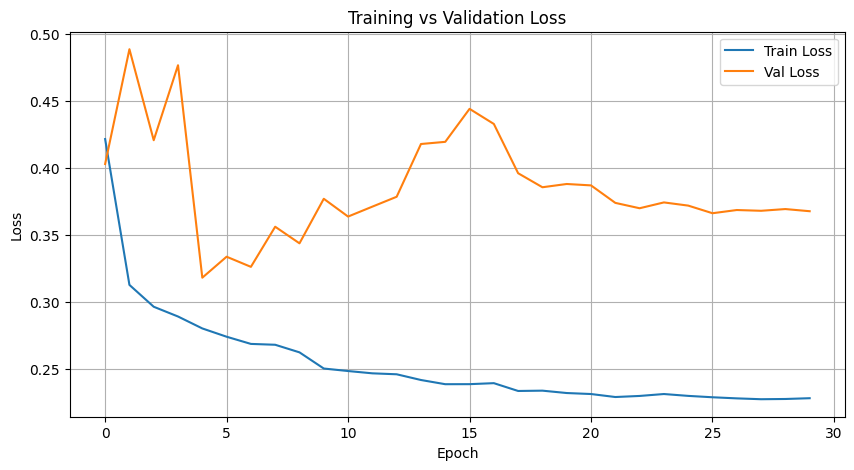

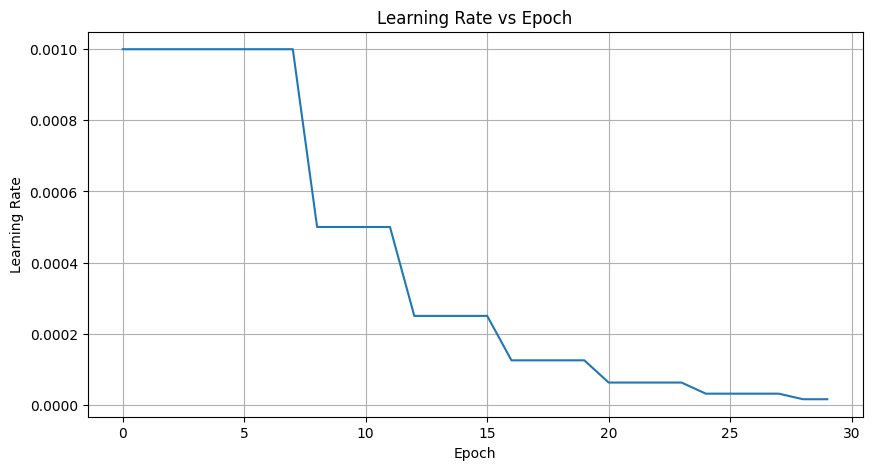

In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

n_epocas = 30

train_losses = []
val_losses = []
lrs = []

for epoch in range(n_epocas):
    # Train
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Guardar LR actual
    lrs.append(optimizer.param_groups[0]['lr'])

    print(
        f"Epoch {epoch+1} - "
        f"Train Loss: {epoch_loss:.4f} - "
        f"Val Loss: {val_loss:.4f} - "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}")


# GRAFICAR LOSS
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

# GRAFICAR LEARNING RATE
plt.figure(figsize=(10,5))
plt.plot(lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epoch")
plt.grid(True)
plt.show()

### Función para recuperar la escala original

In [14]:
def inverse_transform_corregida(y_norm, scaler, trend_coef, start_idx):
    """
    Transformación inversa SIN data leakage
    """
    # Convertir a numpy si es tensor
    if isinstance(y_norm, torch.Tensor):
        y_norm = y_norm.detach().cpu().numpy()
    
    y_norm = np.asarray(y_norm)
    
    # Reshape para scaler
    if y_norm.ndim == 1:
        y_norm = y_norm.reshape(-1, 1)
    
    # 1. Desnormalizar
    y_detrended = scaler.inverse_transform(y_norm)
    
    # 2. Añadir tendencia en posición correcta
    n_samples = len(y_detrended)
    time_positions = np.arange(start_idx, start_idx + n_samples)
    trend_values = np.polyval(trend_coef, time_positions)
    
    return y_detrended.flatten() + trend_values

### Evaluación del modelo

In [15]:
def evaluate_model(model, test_loader, transform_params, device="cpu"):
    """
    Evaluación con transformación inversa correcta
    """
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())

    # Concatenar
    preds_norm = np.concatenate(preds, axis=0)
    trues_norm = np.concatenate(trues, axis=0)

    # Parámetros para inversa
    scaler = transform_params['scaler']
    trend_coef = transform_params['trend_coef']
    start_idx = transform_params['test_start_idx']

    # Transformar a escala original
    trues_original = inverse_transform_corregida(trues_norm, scaler, trend_coef, start_idx)
    preds_original = inverse_transform_corregida(preds_norm, scaler, trend_coef, start_idx)

    # Métricas
    rmse = np.sqrt(mean_squared_error(trues_original, preds_original))
    mae = mean_absolute_error(trues_original, preds_original)
    r2 = r2_score(trues_original, preds_original)

    return {
        "scaler": scaler,
        "trend_coef": trend_coef,
        "start_idx": start_idx,
        "y_true": trues_original,
        "y_pred": preds_original,
        "rmse": rmse,
        "mae": mae,
        "r2": r2}

transform_params = {
    "scaler": scaler_y,
    "trend_coef": resultados['trend_coef'],
    "test_start_idx": idx_test_start}

result = evaluate_model(model, test_loader, transform_params)

y_test_real = result["y_true"]
y_test_pred  = result["y_pred"]
rmse = np.round(result["rmse"], 4)
mae = np.round(result["mae"], 4)
r2 = np.round(result["r2"], 4)

n_test = len(y_test_real)
test_indices = np.arange(idx_test_start, idx_test_start + n_test)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


RMSE: 0.0405
MAE: 0.0316
R²: 0.6307


### Visualización

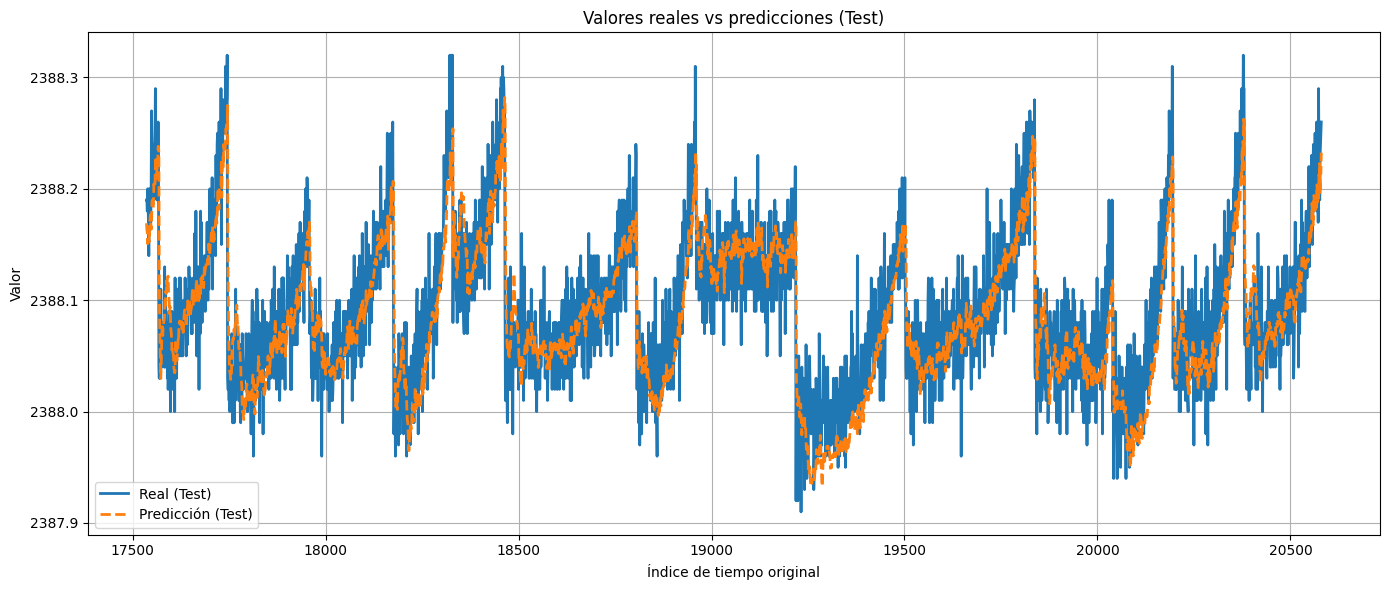

In [16]:
def plot_test_predictions_with_index(indices, y_test_real, y_test_pred, title="Valores reales vs predicciones (Test)"):
    plt.figure(figsize=(14, 6))
    plt.plot(indices, y_test_real, label="Real (Test)", linewidth=2)
    plt.plot(indices, y_test_pred, label="Predicción (Test)", linestyle="--", linewidth=2)
    plt.title(title)
    plt.xlabel("Índice de tiempo original")
    plt.ylabel("Valor")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_test_predictions_with_index(test_indices, y_test_real, y_test_pred)


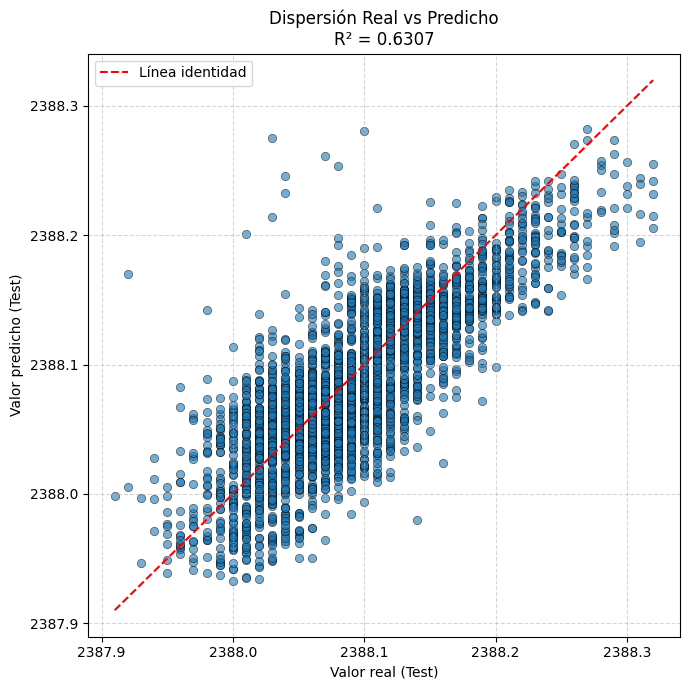

In [17]:
def plot_r2_scatter(y_true, y_pred, title="Dispersión Real vs Predicho"):
    # Asegurar forma correcta
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # Calcular R²
    r2 = r2_score(y_true, y_pred)

    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolor="k", linewidth=0.5)
    
    # Línea identidad (y = x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Línea identidad")

    plt.title(f"{title}\nR² = {r2:.4f}")
    plt.xlabel("Valor real (Test)")
    plt.ylabel("Valor predicho (Test)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_r2_scatter(y_test_real, y_test_pred)

### Guardar el modelo

In [18]:
def guardar_modelo_pesos(model, filepath='modelo_cnn.pth'):
    """
    Guarda SOLO los pesos del modelo (más ligero)
    """
    # Crear directorio
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    
    # Guardar pesos
    torch.save(model.state_dict(), filepath)
    print(f"Modelo guardado en: {filepath}")
    print(f"Tamaño: {os.path.getsize(filepath) / 1024:.1f} KB")